In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [4]:
from sklearn.datasets import fetch_california_housing

# 1. Carrega o dataset
housing = fetch_california_housing(as_frame=True)
analise = housing.frame

In [5]:
analise.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [6]:
# MedHouseVal -> valor médio da casa -> y

In [7]:
# Vou ver qual das duas tem mais correlação para usar como atributo -> O exercício é sobre regressão linear, sem usar bibliotecas, e a pura mesmo ( 1 atributo )

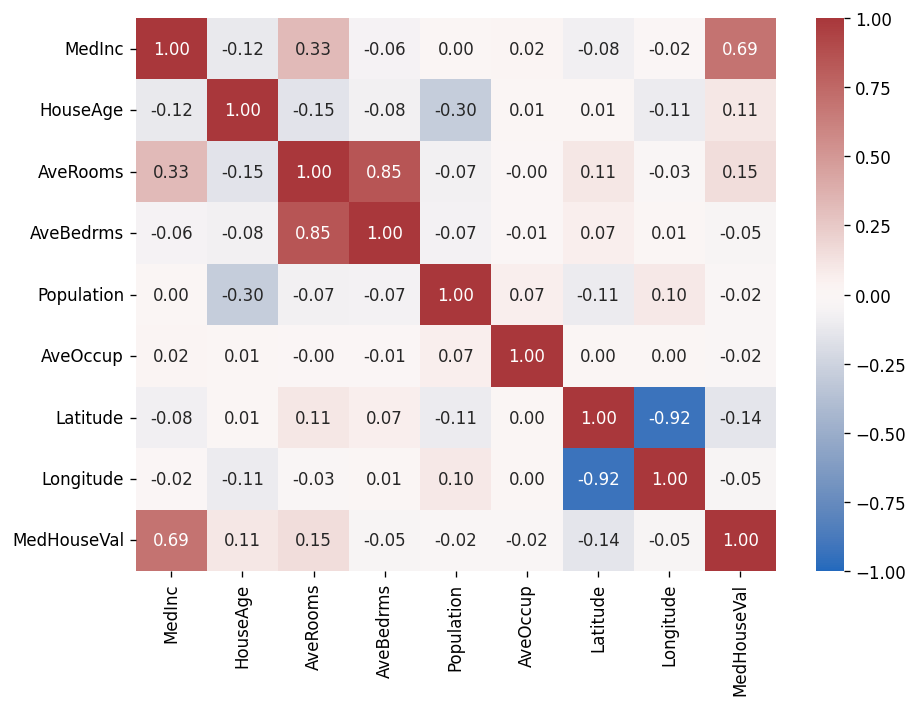

In [8]:
corr = analise.corr()
fig, ax = plt.subplots(figsize=(8,6), dpi=120)
sns.heatmap(corr, annot=True, fmt=".2f", cmap='vlag', center=0, vmin=-1, vmax=1, ax=ax)
fig.tight_layout()
plt.show()

In [9]:
df = analise[['MedInc', 'MedHouseVal']].copy()

C:\Users\RAFAEL\AppData\Local\Temp\ipykernel_18828\964070009.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


<Axes: xlabel='MedHouseVal', ylabel='MedInc'>

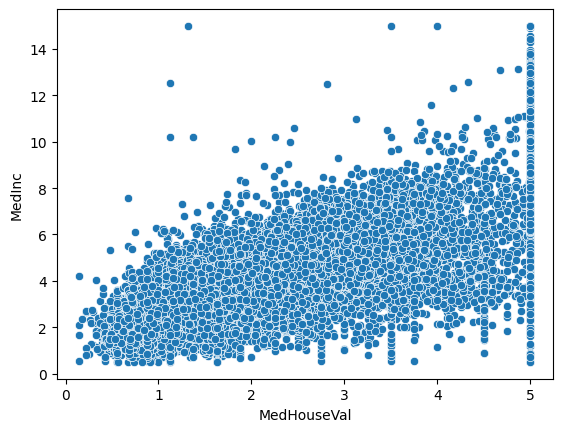

In [10]:
fig, ax = plt.subplots()

sns.scatterplot(
    data=df, 
    y="MedInc", 
    x="MedHouseVal",
    palette="colorblind",
    ax=ax
)

In [21]:
# Como não tem diferença vou manter o original
X = df['MedInc'].to_numpy()
Y = df['MedHouseVal'].to_numpy()

train_pct_index = int(0.1 * len(X))
X_train, X_test = X[:train_pct_index], X[train_pct_index:]
y_train, y_test = Y[:train_pct_index], Y[train_pct_index:]

print(len(X_train)) # 80% -> não sei como shufflar sem uma biblioteca e não queria usar uma também
print(len(X_test))

2064
18576


In [ ]:
class LMSTrainer:

    def __init__(self, a, iter, limiar):

        self.w0, self.w1 = 0,0 # pesos
        self.a = a # taxa de aprendizagem
        self.iter = iter # quantidade de iterações = epochs
        self.limiar = limiar

    def train(self, x, y):
        

        for i in range(self.iter) :

            # predição do modelo
            y_pred = self.w0 + self.w1 * x
            
            #print("Erro médio -> ", (1/len(x)) * np.sum((y_pred - y)**2))

            #                   a        1/m       E(h0(x) - y)                                       
            w0_t = self.w0 - self.a * (1/len(x)) * np.sum((y_pred - y))
            # Esse aqui é o que vou fazer nos outros
            w1_t = self.w1 - self.a * (1/len(x)) * np.sum((y_pred - y) * x)

            self.w0 = w0_t
            self.w1 = w1_t

        return self.w0, self.w1

In [23]:
modelo_regressao_linear = LMSTrainer(
    a=0.001,
    iter=10,
    limiar=0.001
)
vetores_peso = modelo_regressao_linear.train(X_train, y_train)
print(vetores_peso)

x ->  [8.3252 8.3014 7.2574 ... 1.6602 3.5781 3.3438]
y_pred ->  [0. 0. 0. ... 0. 0. 0.]
y ->  [4.526 3.585 3.521 ... 0.612 0.928 0.926]
x ->  [8.3252 8.3014 7.2574 ... 1.6602 3.5781 3.3438]
y_pred ->  [0.0744394  0.07423198 0.06513323 ... 0.0163521  0.03306713 0.03102514]
y ->  [4.526 3.585 3.521 ... 0.612 0.928 0.926]
x ->  [8.3252 8.3014 7.2574 ... 1.6602 3.5781 3.3438]
y_pred ->  [0.14744878 0.14703792 0.12901532 ... 0.03239075 0.06549949 0.06145477]
y ->  [4.526 3.585 3.521 ... 0.612 0.928 0.926]
x ->  [8.3252 8.3014 7.2574 ... 1.6602 3.5781 3.3438]
y_pred ->  [0.21905559 0.2184452  0.1916703  ... 0.04812195 0.09730929 0.09130032]
y ->  [4.526 3.585 3.521 ... 0.612 0.928 0.926]
x ->  [8.3252 8.3014 7.2574 ... 1.6602 3.5781 3.3438]
y_pred ->  [0.28928677 0.2884807  0.25312173 ... 0.06355161 0.12850847 0.12057302]
y ->  [4.526 3.585 3.521 ... 0.612 0.928 0.926]
x ->  [8.3252 8.3014 7.2574 ... 1.6602 3.5781 3.3438]
y_pred ->  [0.35816874 0.35717074 0.31339272 ... 0.07868552 0.1591087

In [14]:
class LMSPredictor:
    def __init__(self, w0, w1):
        self.w0 = w0
        self.w1 = w1

    def predict(self, x):
        a = self.w0 + self.w1*x
        print("w0 = ", self.w0)
        print("w1 = ", self.w1)
        print("x = ", x)
        return a

In [15]:
preditor = LMSPredictor(vetores_peso[0], vetores_peso[1])

In [16]:
print(f"Entrada: " ,X_test[0], ", saída -> ", y_test[0])
a = X_test[0]
print(f"Entrada: " ,X_test[0], ", saída -> ", preditor.predict(a))

Entrada:  2.6368 , saída ->  1.656
w0 =  0.018637846615112627
w1 =  0.08375580232156933
x =  2.6368
Entrada:  2.6368 , saída ->  0.23948514617662664
